In [1]:
from __future__ import annotations

import gc
import json
import math
import shutil
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)


print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

if not tf.config.list_physical_devices("GPU"):
    raise RuntimeError(
        "GPU was not detected. Enable a Kaggle GPU accelerator."
    )


RANDOM_SEED = 42
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
NUMBER_OF_CLASSES = 43

# Change this value to 16 if an out-of-memory error occurs.
BATCH_SIZE = 32

tf.keras.utils.set_random_seed(
    RANDOM_SEED
)

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
INPUT_ROOT = Path(
    "/kaggle/input"
)


def find_gtsrb_root() -> Path:
    # Find the GTSRB directory using its CSV files and image folders.
    for train_csv in INPUT_ROOT.rglob(
        "Train.csv"
    ):
        candidate = train_csv.parent

        if (
            (candidate / "Test.csv").exists()
            and (candidate / "Train").is_dir()
            and (candidate / "Test").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "The GTSRB dataset root was not found."
    )


def find_model_file(
    filename: str,
) -> Path:
    # Search recursively because Kaggle may add extra directory levels.
    matches = sorted(
        INPUT_ROOT.rglob(filename),
        key=lambda path: (
            len(path.parts),
            str(path),
        ),
    )

    if not matches:
        raise FileNotFoundError(
            f"The model file was not found: {filename}"
        )

    if len(matches) > 1:
        print(
            f"Warning: multiple matches found for {filename}"
        )

        for match in matches:
            print(" ", match)

        print("Using:", matches[0])

    return matches[0]


DATASET_ROOT = find_gtsrb_root()


MODEL_PATHS = {
    "Custom CNN": find_model_file(
        "best_custom_cnn.keras"
    ),

    "EfficientNetV2B0": find_model_file(
        "best_efficientnetv2b0.keras"
    ),

    "ConvNeXtTiny": find_model_file(
        "best_convnexttiny.keras"
    ),
}


print("GTSRB root:")
print(DATASET_ROOT)

print("\nModel files:")

for model_name, model_path in MODEL_PATHS.items():
    print(
        f"{model_name}: {model_path}"
    )

GTSRB root:
/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

Model files:
Custom CNN: /kaggle/input/datasets/yuriyrizoboyev/traffic-sign-best-models/best_custom_cnn.keras
EfficientNetV2B0: /kaggle/input/datasets/yuriyrizoboyev/traffic-sign-best-models/best_efficientnetv2b0.keras
ConvNeXtTiny: /kaggle/input/datasets/yuriyrizoboyev/traffic-sign-best-models/best_convnexttiny.keras


In [3]:
OUTPUT_ROOT = Path(
    "/kaggle/working/robustness_outputs"
)

REPORT_DIR = (
    OUTPUT_ROOT
    / "reports"
)

FIGURE_DIR = (
    OUTPUT_ROOT
    / "figures"
)

PREDICTION_DIR = (
    OUTPUT_ROOT
    / "predictions"
)

CLASS_REPORT_DIR = (
    OUTPUT_ROOT
    / "classification_reports"
)


for directory in [
    OUTPUT_ROOT,
    REPORT_DIR,
    FIGURE_DIR,
    PREDICTION_DIR,
    CLASS_REPORT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print(
    "Output root:",
    OUTPUT_ROOT,
)

Output root: /kaggle/working/robustness_outputs


In [4]:
test_frame = pd.read_csv(
    DATASET_ROOT
    / "Test.csv"
)


required_columns = [
    "Path",
    "ClassId",
]


missing_columns = [
    column
    for column in required_columns
    if column not in test_frame.columns
]


if missing_columns:
    raise KeyError(
        f"Missing Test.csv columns: {missing_columns}"
    )


def resolve_image_path(
    relative_path: str,
) -> str:
    # Normalize Windows-style and Unix-style path separators.
    normalized = (
        str(relative_path)
        .replace("\\", "/")
        .lstrip("/")
    )

    return str(
        DATASET_ROOT
        / normalized
    )


test_frame[
    "absolute_path"
] = test_frame[
    "Path"
].map(
    resolve_image_path
)


missing_images = [
    path
    for path in test_frame[
        "absolute_path"
    ]
    if not Path(path).exists()
]


if missing_images:
    raise FileNotFoundError(
        f"{len(missing_images)} test images were not found. "
        f"First missing path: {missing_images[0]}"
    )


if len(test_frame) != 12630:
    raise ValueError(
        f"Expected 12630 test images, "
        f"found {len(test_frame)}."
    )


if (
    test_frame["ClassId"].nunique()
    != NUMBER_OF_CLASSES
):
    raise ValueError(
        "The test set does not contain all 43 classes."
    )


TEST_PATHS = (
    test_frame[
        "absolute_path"
    ]
    .astype(str)
    .to_numpy()
)

TRUE_LABELS = (
    test_frame[
        "ClassId"
    ]
    .astype(np.int64)
    .to_numpy()
)

TEST_INDICES = np.arange(
    len(test_frame),
    dtype=np.int64,
)


print(
    "Test images:",
    len(test_frame),
)

print(
    "Classes:",
    test_frame["ClassId"].nunique(),
)

display(
    test_frame[
        [
            "Path",
            "ClassId",
        ]
    ].head()
)

Test images: 12630
Classes: 43


,Path,ClassId
0,Test/00000.png,16
1,Test/00001.png,1
2,Test/00002.png,38
3,Test/00003.png,33
4,Test/00004.png,11


In [5]:
CONDITIONS = [
    {
        "name": "clean",
        "label": "Clean",
        "kind": "clean",
        "value": 0.0,
        "order": 0,
    },

    {
        "name": "low_light_060",
        "label": "Low light 0.60",
        "kind": "brightness",
        "value": 0.60,
        "order": 1,
    },

    {
        "name": "low_light_030",
        "label": "Low light 0.30",
        "kind": "brightness",
        "value": 0.30,
        "order": 2,
    },

    {
        "name": "gaussian_blur_sigma_1",
        "label": "Gaussian blur sigma 1",
        "kind": "blur",
        "value": 1.0,
        "order": 3,
    },

    {
        "name": "gaussian_blur_sigma_2",
        "label": "Gaussian blur sigma 2",
        "kind": "blur",
        "value": 2.0,
        "order": 4,
    },

    {
        "name": "gaussian_noise_std_10",
        "label": "Gaussian noise std 10",
        "kind": "noise",
        "value": 10.0,
        "order": 5,
    },

    {
        "name": "gaussian_noise_std_25",
        "label": "Gaussian noise std 25",
        "kind": "noise",
        "value": 25.0,
        "order": 6,
    },

    {
        "name": "central_occlusion_015",
        "label": "Central occlusion 15%",
        "kind": "occlusion",
        "value": 0.15,
        "order": 7,
    },

    {
        "name": "central_occlusion_030",
        "label": "Central occlusion 30%",
        "kind": "occlusion",
        "value": 0.30,
        "order": 8,
    },
]


condition_frame = pd.DataFrame(
    CONDITIONS
)

display(
    condition_frame
)

,name,label,kind,value,order
0,clean,Clean,clean,0.00,0
1,low_light_060,Low light 0.60,brightness,0.60,1
2,low_light_030,Low light 0.30,brightness,0.30,2
3,gaussian_blur_sigma_1,Gaussian blur sigma 1,blur,1.00,3
4,gaussian_blur_sigma_2,Gaussian blur sigma 2,blur,2.00,4
5,gaussian_noise_std_10,Gaussian noise std 10,noise,10.00,5
6,gaussian_noise_std_25,Gaussian noise std 25,noise,25.00,6
7,central_occlusion_015,Central occlusion 15%,occlusion,0.15,7
8,central_occlusion_030,Central occlusion 30%,occlusion,0.30,8


In [6]:
def load_image(
    path: tf.Tensor,
) -> tf.Tensor:
    # Read, decode, resize, and return an RGB image in [0, 255].
    image_bytes = tf.io.read_file(
        path
    )

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )

    image.set_shape(
        [
            None,
            None,
            3,
        ]
    )

    image = tf.image.resize(
        image,
        [
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
        ],
        method="bilinear",
        antialias=True,
    )

    image = tf.cast(
        image,
        tf.float32,
    )

    image = tf.clip_by_value(
        image,
        0.0,
        255.0,
    )

    return tf.ensure_shape(
        image,
        [
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
            3,
        ],
    )


def make_gaussian_kernel(
    sigma: float,
) -> tf.Tensor:
    # Create a Gaussian depthwise-convolution kernel.
    radius = int(
        math.ceil(
            3.0
            * sigma
        )
    )

    coordinates = np.arange(
        -radius,
        radius + 1,
        dtype=np.float32,
    )

    kernel_1d = np.exp(
        -(coordinates ** 2)
        / (
            2.0
            * sigma ** 2
        )
    )

    kernel_1d = (
        kernel_1d
        / kernel_1d.sum()
    )

    kernel_2d = np.outer(
        kernel_1d,
        kernel_1d,
    )

    kernel_2d = (
        kernel_2d
        / kernel_2d.sum()
    )

    kernel = kernel_2d[
        :,
        :,
        np.newaxis,
        np.newaxis,
    ]

    kernel = np.tile(
        kernel,
        [
            1,
            1,
            3,
            1,
        ],
    )

    return tf.constant(
        kernel,
        dtype=tf.float32,
    )


def make_occlusion_mask(
    area_fraction: float,
) -> tf.Tensor:
    # Create a centered square mask covering the requested image area.
    side = int(
        round(
            math.sqrt(
                area_fraction
            )
            * min(
                IMAGE_HEIGHT,
                IMAGE_WIDTH,
            )
        )
    )

    side = max(
        1,
        min(
            side,
            min(
                IMAGE_HEIGHT,
                IMAGE_WIDTH,
            ),
        ),
    )

    top = (
        IMAGE_HEIGHT
        - side
    ) // 2

    left = (
        IMAGE_WIDTH
        - side
    ) // 2

    bottom = (
        IMAGE_HEIGHT
        - side
        - top
    )

    right = (
        IMAGE_WIDTH
        - side
        - left
    )

    blocked_region = tf.ones(
        [
            side,
            side,
            3,
        ],
        dtype=tf.float32,
    )

    blocked_region = tf.pad(
        blocked_region,
        [
            [
                top,
                bottom,
            ],
            [
                left,
                right,
            ],
            [
                0,
                0,
            ],
        ],
    )

    mask = (
        1.0
        - blocked_region
    )

    return tf.ensure_shape(
        mask,
        [
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
            3,
        ],
    )


GAUSSIAN_KERNELS = {
    1.0: make_gaussian_kernel(
        1.0
    ),

    2.0: make_gaussian_kernel(
        2.0
    ),
}


OCCLUSION_MASKS = {
    0.15: make_occlusion_mask(
        0.15
    ),

    0.30: make_occlusion_mask(
        0.30
    ),
}


def apply_condition(
    image: tf.Tensor,
    image_index: tf.Tensor,
    condition: dict[str, Any],
) -> tf.Tensor:
    # Apply a deterministic corruption in the [0, 255] range.
    kind = condition[
        "kind"
    ]

    value = float(
        condition[
            "value"
        ]
    )

    if kind == "clean":
        corrupted = image

    elif kind == "brightness":
        corrupted = (
            image
            * value
        )

    elif kind == "blur":
        kernel = GAUSSIAN_KERNELS[
            value
        ]

        corrupted = tf.nn.depthwise_conv2d(
            image[
                tf.newaxis,
                ...
            ],
            kernel,
            strides=[
                1,
                1,
                1,
                1,
            ],
            padding="SAME",
        )[0]

    elif kind == "noise":
        seed = tf.stack(
            [
                tf.constant(
                    RANDOM_SEED,
                    dtype=tf.int32,
                ),

                tf.cast(
                    image_index,
                    tf.int32,
                ),
            ]
        )

        noise = tf.random.stateless_normal(
            shape=tf.shape(
                image
            ),
            seed=seed,
            mean=0.0,
            stddev=value,
            dtype=tf.float32,
        )

        corrupted = (
            image
            + noise
        )

    elif kind == "occlusion":
        corrupted = (
            image
            * OCCLUSION_MASKS[
                value
            ]
        )

    else:
        raise ValueError(
            f"Unsupported condition: {kind}"
        )

    corrupted = tf.clip_by_value(
        corrupted,
        0.0,
        255.0,
    )

    return tf.ensure_shape(
        corrupted,
        [
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
            3,
        ],
    )

I0000 00:00:1784753789.110781      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [7]:
MODEL_INPUT_RANGES = {
    "Custom CNN": "zero_one",
    "EfficientNetV2B0": "zero_255",
    "ConvNeXtTiny": "zero_255",
}


def prepare_model_input(
    image: tf.Tensor,
    input_range: str,
) -> tf.Tensor:
    # Match the preprocessing used during model training.
    if input_range == "zero_one":
        return (
            image
            / 255.0
        )

    if input_range == "zero_255":
        return image

    raise ValueError(
        f"Unsupported input range: {input_range}"
    )


def build_prediction_dataset(
    condition: dict[str, Any],
    input_range: str,
) -> tf.data.Dataset:
    # Preserve the original Test.csv order.
    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                TEST_INDICES,
                TEST_PATHS,
            )
        )
    )

    options = tf.data.Options()

    options.experimental_deterministic = (
        True
    )

    dataset = dataset.with_options(
        options
    )

    def map_example(
        image_index: tf.Tensor,
        image_path: tf.Tensor,
    ) -> tf.Tensor:
        image = load_image(
            image_path
        )

        image = apply_condition(
            image,
            image_index,
            condition,
        )

        image = prepare_model_input(
            image,
            input_range,
        )

        return image

    dataset = dataset.map(
        map_example,
        num_parallel_calls=(
            tf.data.AUTOTUNE
        ),
        deterministic=True,
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False,
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

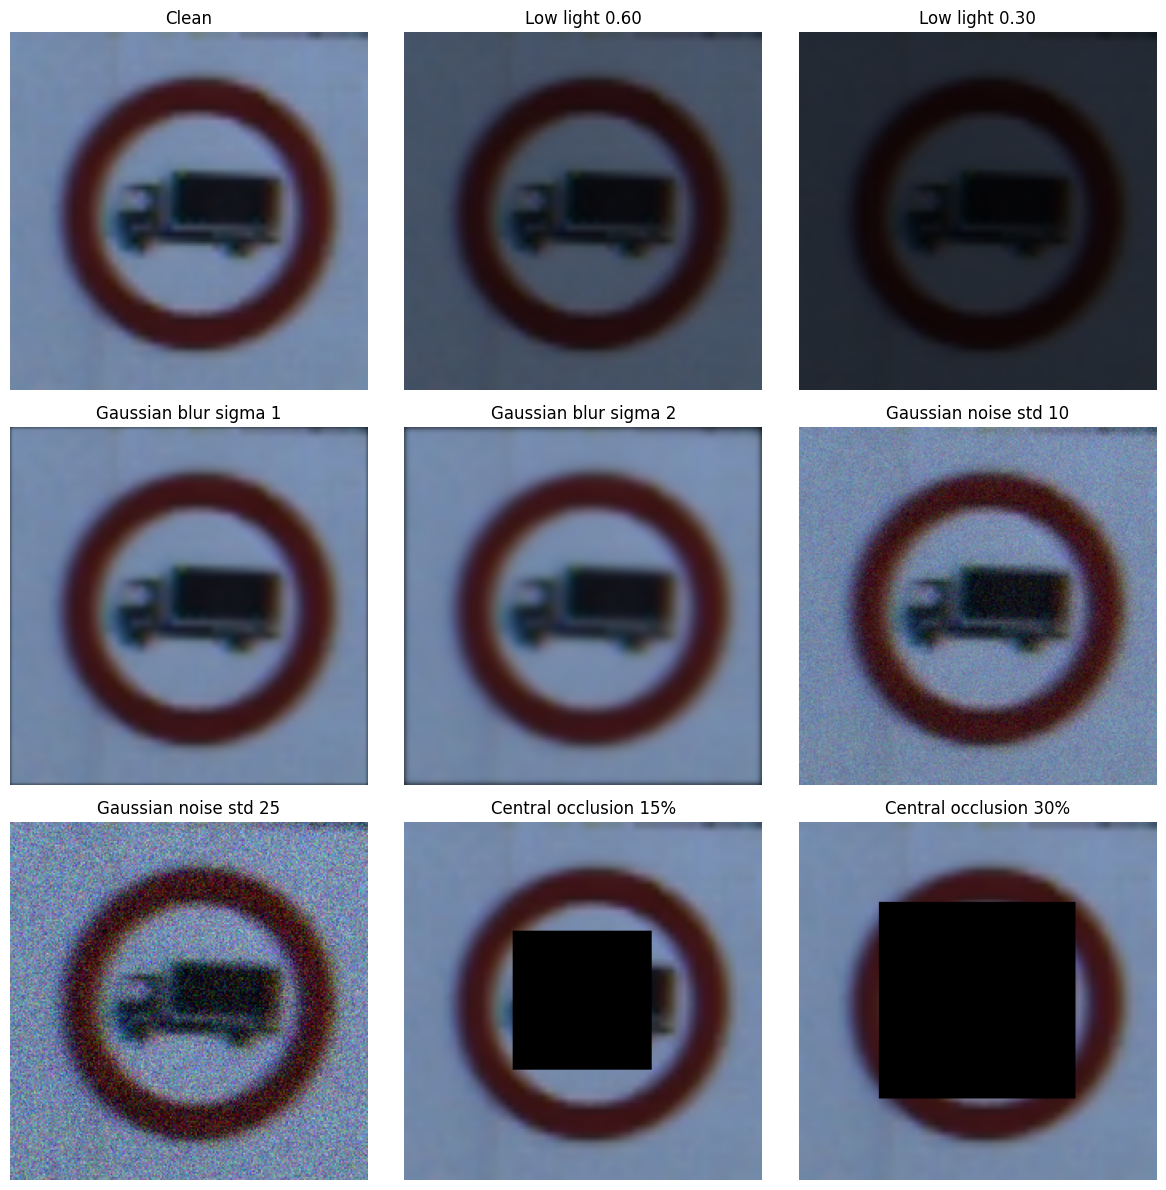

In [8]:
sample_path = tf.constant(
    TEST_PATHS[0]
)

sample_index = tf.constant(
    TEST_INDICES[0]
)

sample_image = load_image(
    sample_path
)


figure, axes = plt.subplots(
    3,
    3,
    figsize=(
        12,
        12,
    ),
)


for axis, condition in zip(
    axes.ravel(),
    CONDITIONS,
):
    corrupted = apply_condition(
        sample_image,
        sample_index,
        condition,
    )

    axis.imshow(
        corrupted.numpy().astype(
            np.uint8
        )
    )

    axis.set_title(
        condition[
            "label"
        ]
    )

    axis.axis(
        "off"
    )


plt.tight_layout()


plt.savefig(
    FIGURE_DIR
    / "corruption_examples.pdf",
    bbox_inches="tight",
)


plt.savefig(
    FIGURE_DIR
    / "corruption_examples.png",
    dpi=180,
    bbox_inches="tight",
)


plt.show()

In [9]:
def calculate_metrics(
    probabilities: np.ndarray,
    true_labels: np.ndarray,
) -> dict[str, float]:
    # Calculate classification metrics from predicted probabilities.
    predicted_labels = np.argmax(
        probabilities,
        axis=1,
    )

    top3_classes = np.argsort(
        probabilities,
        axis=1,
    )[
        :,
        -3:
    ][
        :,
        ::-1
    ]

    top3_correct = np.any(
        top3_classes
        == true_labels[
            :,
            None,
        ],
        axis=1,
    )

    return {
        "accuracy": float(
            accuracy_score(
                true_labels,
                predicted_labels,
            )
        ),

        "macro_precision": float(
            precision_score(
                true_labels,
                predicted_labels,
                average="macro",
                zero_division=0,
            )
        ),

        "macro_recall": float(
            recall_score(
                true_labels,
                predicted_labels,
                average="macro",
                zero_division=0,
            )
        ),

        "macro_f1": float(
            f1_score(
                true_labels,
                predicted_labels,
                average="macro",
                zero_division=0,
            )
        ),

        "weighted_f1": float(
            f1_score(
                true_labels,
                predicted_labels,
                average="weighted",
                zero_division=0,
            )
        ),

        "top3_accuracy": float(
            top3_correct.mean()
        ),
    }


def safe_filename(
    value: str,
) -> str:
    # Convert a model name into a safe lowercase filename.
    return (
        value
        .lower()
        .replace(
            " ",
            "_",
        )
        .replace(
            "-",
            "_",
        )
    )

In [10]:
for model_name, model_path in MODEL_PATHS.items():
    tf.keras.backend.clear_session()

    gc.collect()

    model = tf.keras.models.load_model(
        model_path,
        compile=False,
    )

    print()
    print(model_name)

    print(
        "Input shape:",
        model.input_shape,
    )

    print(
        "Output shape:",
        model.output_shape,
    )

    print(
        "Parameters:",
        model.count_params(),
    )

    if tuple(
        model.input_shape[1:]
    ) != (
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        3,
    ):
        raise ValueError(
            f"{model_name} has an invalid input shape: "
            f"{model.input_shape}"
        )

    if int(
        model.output_shape[-1]
    ) != NUMBER_OF_CLASSES:
        raise ValueError(
            f"{model_name} has an invalid output shape: "
            f"{model.output_shape}"
        )

    del model


tf.keras.backend.clear_session()

gc.collect()


print(
    "\nAll model shapes are valid."
)


Custom CNN
Input shape: (None, 224, 224, 3)
Output shape: (None, 43)
Parameters: 661899

EfficientNetV2B0
Input shape: (None, 224, 224, 3)
Output shape: (None, 43)
Parameters: 6263419

ConvNeXtTiny
Input shape: (None, 224, 224, 3)
Output shape: (None, 43)
Parameters: 28029579

All model shapes are valid.


In [11]:
clean_condition = CONDITIONS[0]


for model_name, model_path in MODEL_PATHS.items():
    tf.keras.backend.clear_session()

    gc.collect()

    model = tf.keras.models.load_model(
        model_path,
        compile=False,
    )

    dataset = build_prediction_dataset(
        clean_condition,
        MODEL_INPUT_RANGES[
            model_name
        ],
    )

    first_batch = next(
        iter(
            dataset.take(1)
        )
    )

    output = model(
        first_batch,
        training=False,
    )

    print(
        model_name,
        "| input:",
        first_batch.shape,
        "| output:",
        output.shape,
    )

    if (
        output.shape[-1]
        != NUMBER_OF_CLASSES
    ):
        raise ValueError(
            f"{model_name} returned an invalid output."
        )

    del model
    del dataset
    del first_batch
    del output


tf.keras.backend.clear_session()

gc.collect()


print(
    "Smoke tests completed successfully."
)

Custom CNN | input: (32, 224, 224, 3) | output: (32, 43)
EfficientNetV2B0 | input: (32, 224, 224, 3) | output: (32, 43)


I0000 00:00:1784753812.319864      23 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ConvNeXtTiny | input: (32, 224, 224, 3) | output: (32, 43)
Smoke tests completed successfully.


In [12]:
all_results: list[
    dict[str, Any]
] = []


for model_name, model_path in MODEL_PATHS.items():
    print()
    print("=" * 80)

    print(
        "Loading model:",
        model_name,
    )

    print(
        "Path:",
        model_path,
    )

    print("=" * 80)


    tf.keras.backend.clear_session()

    gc.collect()


    model = tf.keras.models.load_model(
        model_path,
        compile=False,
    )


    input_range = MODEL_INPUT_RANGES[
        model_name
    ]


    model_file_size_mb = (
        model_path.stat().st_size
        / 1024
        / 1024
    )


    parameter_count = int(
        model.count_params()
    )


    for condition in CONDITIONS:
        print()
        print("-" * 80)

        print(
            f"Model: {model_name} | "
            f"Condition: {condition['label']}"
        )

        print("-" * 80)


        prediction_dataset = (
            build_prediction_dataset(
                condition,
                input_range,
            )
        )


        # Run one warm-up batch before measuring inference time.
        warmup_batch = next(
            iter(
                prediction_dataset.take(1)
            )
        )


        _ = model(
            warmup_batch,
            training=False,
        )


        prediction_start = (
            time.perf_counter()
        )


        probabilities = model.predict(
            prediction_dataset,
            verbose=1,
        )


        prediction_seconds = (
            time.perf_counter()
            - prediction_start
        )


        expected_shape = (
            len(TRUE_LABELS),
            NUMBER_OF_CLASSES,
        )


        if probabilities.shape != expected_shape:
            raise ValueError(
                f"Unexpected probability shape: "
                f"{probabilities.shape}; "
                f"expected {expected_shape}."
            )


        metrics = calculate_metrics(
            probabilities,
            TRUE_LABELS,
        )


        predicted_labels = np.argmax(
            probabilities,
            axis=1,
        )


        confidence = np.max(
            probabilities,
            axis=1,
        )


        top3_classes = np.argsort(
            probabilities,
            axis=1,
        )[
            :,
            -3:
        ][
            :,
            ::-1
        ]


        result_row = {
            "model": model_name,

            "condition": condition[
                "name"
            ],

            "condition_label": condition[
                "label"
            ],

            "condition_order": condition[
                "order"
            ],

            "condition_kind": condition[
                "kind"
            ],

            "condition_value": condition[
                "value"
            ],

            "test_images": int(
                len(TRUE_LABELS)
            ),

            **metrics,

            "prediction_seconds": float(
                prediction_seconds
            ),

            "milliseconds_per_image": float(
                prediction_seconds
                / len(TRUE_LABELS)
                * 1000.0
            ),

            "images_per_second": float(
                len(TRUE_LABELS)
                / prediction_seconds
            ),

            "parameter_count": (
                parameter_count
            ),

            "model_file_size_mb": float(
                model_file_size_mb
            ),
        }


        all_results.append(
            result_row
        )


        print(
            json.dumps(
                result_row,
                indent=2,
            )
        )


        model_key = safe_filename(
            model_name
        )


        condition_key = condition[
            "name"
        ]


        prediction_frame = pd.DataFrame(
            {
                "Path": test_frame[
                    "Path"
                ],

                "true_class_id": (
                    TRUE_LABELS
                ),

                "predicted_class_id": (
                    predicted_labels
                ),

                "confidence": (
                    confidence
                ),

                "correct": (
                    predicted_labels
                    == TRUE_LABELS
                ),

                "top1_class_id": (
                    top3_classes[
                        :,
                        0
                    ]
                ),

                "top2_class_id": (
                    top3_classes[
                        :,
                        1
                    ]
                ),

                "top3_class_id": (
                    top3_classes[
                        :,
                        2
                    ]
                ),
            }
        )


        prediction_frame.to_csv(
            PREDICTION_DIR
            / (
                f"{model_key}__"
                f"{condition_key}.csv"
            ),
            index=False,
        )


        report = classification_report(
            TRUE_LABELS,
            predicted_labels,
            labels=list(
                range(
                    NUMBER_OF_CLASSES
                )
            ),
            output_dict=True,
            zero_division=0,
        )


        pd.DataFrame(
            report
        ).transpose().to_csv(
            CLASS_REPORT_DIR
            / (
                f"{model_key}__"
                f"{condition_key}.csv"
            )
        )


        del prediction_dataset
        del warmup_batch
        del probabilities
        del prediction_frame

        gc.collect()


    del model

    tf.keras.backend.clear_session()

    gc.collect()


print()
print(
    "Completed evaluation runs:",
    len(all_results),
)


expected_runs = (
    len(MODEL_PATHS)
    * len(CONDITIONS)
)


if len(all_results) != expected_runs:
    raise RuntimeError(
        f"Expected {expected_runs} runs, "
        f"but completed {len(all_results)}."
    )


Loading model: Custom CNN
Path: /kaggle/input/datasets/yuriyrizoboyev/traffic-sign-best-models/best_custom_cnn.keras

--------------------------------------------------------------------------------
Model: Custom CNN | Condition: Clean
--------------------------------------------------------------------------------
395/395 ━━━━━━━━━━━━━━━━━━━━ 32s 72ms/step
{
  "model": "Custom CNN",
  "condition": "clean",
  "condition_label": "Clean",
  "condition_order": 0,
  "condition_kind": "clean",
  "condition_value": 0.0,
  "test_images": 12630,
  "accuracy": 0.8536817102137767,
  "macro_precision": 0.8341974202338868,
  "macro_recall": 0.8143875039501935,
  "macro_f1": 0.8050580967378168,
  "weighted_f1": 0.8561048961165791,
  "top3_accuracy": 0.9542359461599367,
  "prediction_seconds": 31.737832642000058,
  "milliseconds_per_image": 2.5128925290578032,
  "images_per_second": 397.94777867995214,
  "parameter_count": 661899,
  "model_file_size_mb": 7.696724891662598
}

-----------------------

In [13]:
results_frame = pd.DataFrame(
    all_results
)


results_frame = (
    results_frame
    .sort_values(
        [
            "model",
            "condition_order",
        ]
    )
    .reset_index(
        drop=True
    )
)


clean_metrics = (
    results_frame[
        results_frame[
            "condition"
        ]
        == "clean"
    ][
        [
            "model",
            "accuracy",
            "macro_f1",
            "top3_accuracy",
        ]
    ]
    .rename(
        columns={
            "accuracy":
            "clean_accuracy",

            "macro_f1":
            "clean_macro_f1",

            "top3_accuracy":
            "clean_top3_accuracy",
        }
    )
)


results_frame = results_frame.merge(
    clean_metrics,
    on="model",
    how="left",
)


results_frame[
    "accuracy_drop"
] = (
    results_frame[
        "clean_accuracy"
    ]
    - results_frame[
        "accuracy"
    ]
)


results_frame[
    "macro_f1_drop"
] = (
    results_frame[
        "clean_macro_f1"
    ]
    - results_frame[
        "macro_f1"
    ]
)


results_frame[
    "top3_accuracy_drop"
] = (
    results_frame[
        "clean_top3_accuracy"
    ]
    - results_frame[
        "top3_accuracy"
    ]
)


results_frame[
    "relative_accuracy_drop_percent"
] = np.where(
    results_frame[
        "clean_accuracy"
    ] > 0,

    (
        results_frame[
            "accuracy_drop"
        ]
        / results_frame[
            "clean_accuracy"
        ]
        * 100.0
    ),

    np.nan,
)


results_frame.to_csv(
    REPORT_DIR
    / "robustness_results.csv",
    index=False,
)


rounded_results = (
    results_frame.copy()
)


numeric_columns = (
    rounded_results
    .select_dtypes(
        include=[
            np.number
        ]
    )
    .columns
)


rounded_results[
    numeric_columns
] = rounded_results[
    numeric_columns
].round(
    6
)


rounded_results.to_csv(
    REPORT_DIR
    / "robustness_results_rounded.csv",
    index=False,
)


display(
    rounded_results[
        [
            "model",
            "condition_label",
            "accuracy",
            "macro_f1",
            "top3_accuracy",
            "accuracy_drop",
            "macro_f1_drop",
        ]
    ]
)

,model,condition_label,accuracy,macro_f1,top3_accuracy,accuracy_drop,macro_f1_drop
0,ConvNeXtTiny,Clean,0.934917,0.890261,0.982660,0.000000,0.000000
1,ConvNeXtTiny,Low light 0.60,0.941172,0.895044,0.984561,-0.006255,-0.004784
2,ConvNeXtTiny,Low light 0.30,0.934046,0.886617,0.984086,0.000871,0.003643
3,ConvNeXtTiny,Gaussian blur sigma 1,0.939826,0.894875,0.984402,-0.004909,-0.004614
4,ConvNeXtTiny,Gaussian blur sigma 2,0.935709,0.888880,0.984798,-0.000792,0.001381
5,ConvNeXtTiny,Gaussian noise std 10,0.922407,0.864697,0.983056,0.012510,0.025564
6,ConvNeXtTiny,Gaussian noise std 25,0.867379,0.811002,0.958353,0.067538,0.079259
7,ConvNeXtTiny,Central occlusion 15%,0.449327,0.414549,0.669121,0.485590,0.475712
8,ConvNeXtTiny,Central occlusion 30%,0.220903,0.165265,0.416073,0.714014,0.724996
9,Custom CNN,Clean,0.853682,0.805058,0.954236,0.000000,0.000000


In [14]:
accuracy_table = (
    results_frame.pivot(
        index="condition_label",
        columns="model",
        values="accuracy",
    )
)


macro_f1_table = (
    results_frame.pivot(
        index="condition_label",
        columns="model",
        values="macro_f1",
    )
)


accuracy_drop_table = (
    results_frame.pivot(
        index="condition_label",
        columns="model",
        values="accuracy_drop",
    )
)


macro_f1_drop_table = (
    results_frame.pivot(
        index="condition_label",
        columns="model",
        values="macro_f1_drop",
    )
)


accuracy_table.to_csv(
    REPORT_DIR
    / "accuracy_table.csv"
)


macro_f1_table.to_csv(
    REPORT_DIR
    / "macro_f1_table.csv"
)


accuracy_drop_table.to_csv(
    REPORT_DIR
    / "accuracy_drop_table.csv"
)


macro_f1_drop_table.to_csv(
    REPORT_DIR
    / "macro_f1_drop_table.csv"
)


print(
    "Accuracy table:"
)

display(
    accuracy_table
)


print(
    "Macro F1 drop table:"
)

display(
    macro_f1_drop_table
)

Accuracy table:


model,ConvNeXtTiny,Custom CNN,EfficientNetV2B0
condition_label,,,
Central occlusion 15%,0.449327,0.220507,0.195962
Central occlusion 30%,0.220903,0.116627,0.107205
Clean,0.934917,0.853682,0.847348
Gaussian blur sigma 1,0.939826,0.850594,0.855503
Gaussian blur sigma 2,0.935709,0.838717,0.831116
Gaussian noise std 10,0.922407,0.811560,0.789549
Gaussian noise std 25,0.867379,0.603721,0.626920
Low light 0.30,0.934046,0.664608,0.774505
Low light 0.60,0.941172,0.826049,0.833175


Macro F1 drop table:


model,ConvNeXtTiny,Custom CNN,EfficientNetV2B0
condition_label,,,
Central occlusion 15%,0.475712,0.652097,0.623912
Central occlusion 30%,0.724996,0.756214,0.704500
Clean,0.000000,0.000000,0.000000
Gaussian blur sigma 1,-0.004614,0.000911,-0.022611
Gaussian blur sigma 2,0.001381,0.011292,-0.008800
Gaussian noise std 10,0.025564,0.039236,0.046117
Gaussian noise std 25,0.079259,0.242061,0.204339
Low light 0.30,0.003643,0.182915,0.059627
Low light 0.60,-0.004784,0.031769,0.010958


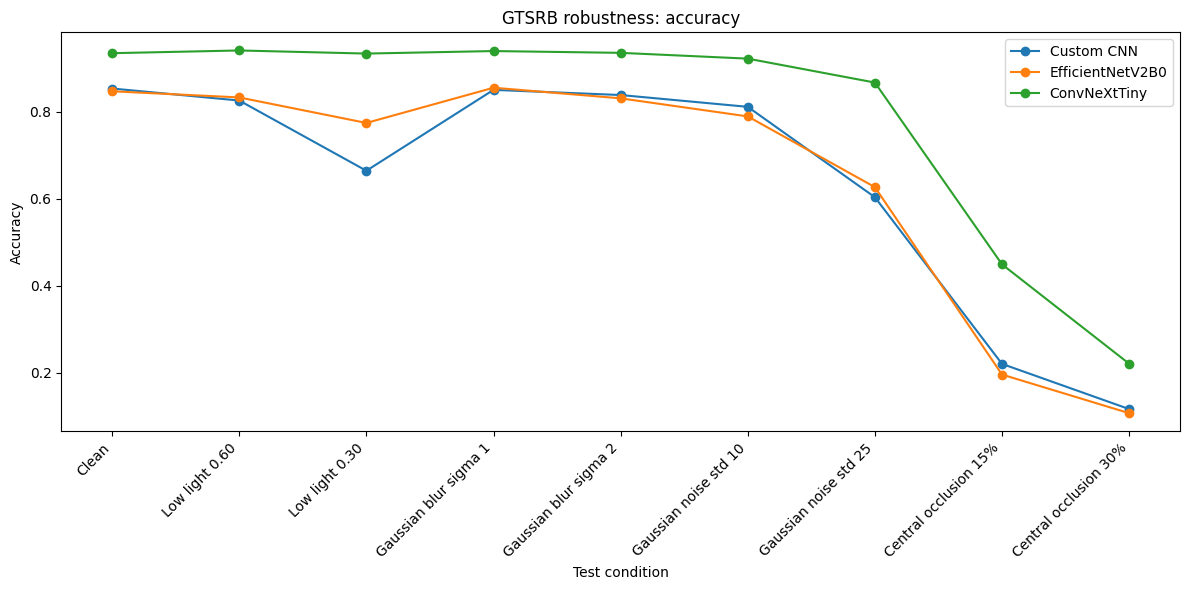

In [15]:
plot_frame = results_frame.sort_values(
    "condition_order"
)


plt.figure(
    figsize=(
        12,
        6,
    )
)


for model_name in MODEL_PATHS:
    model_rows = plot_frame[
        plot_frame[
            "model"
        ]
        == model_name
    ]

    plt.plot(
        model_rows[
            "condition_label"
        ],

        model_rows[
            "accuracy"
        ],

        marker="o",

        label=model_name,
    )


plt.xlabel(
    "Test condition"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "GTSRB robustness: accuracy"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.legend()

plt.tight_layout()


plt.savefig(
    FIGURE_DIR
    / "robustness_accuracy.pdf",
    bbox_inches="tight",
)


plt.savefig(
    FIGURE_DIR
    / "robustness_accuracy.png",
    dpi=180,
    bbox_inches="tight",
)


plt.show()

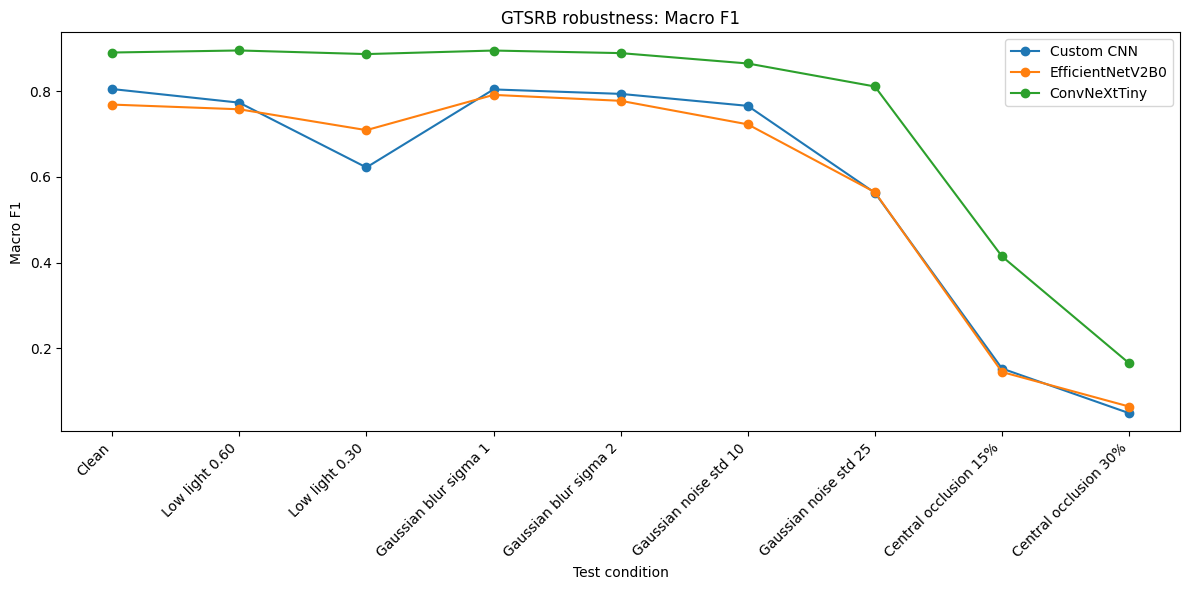

In [16]:
plt.figure(
    figsize=(
        12,
        6,
    )
)


for model_name in MODEL_PATHS:
    model_rows = plot_frame[
        plot_frame[
            "model"
        ]
        == model_name
    ]

    plt.plot(
        model_rows[
            "condition_label"
        ],

        model_rows[
            "macro_f1"
        ],

        marker="o",

        label=model_name,
    )


plt.xlabel(
    "Test condition"
)

plt.ylabel(
    "Macro F1"
)

plt.title(
    "GTSRB robustness: Macro F1"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.legend()

plt.tight_layout()


plt.savefig(
    FIGURE_DIR
    / "robustness_macro_f1.pdf",
    bbox_inches="tight",
)


plt.savefig(
    FIGURE_DIR
    / "robustness_macro_f1.png",
    dpi=180,
    bbox_inches="tight",
)


plt.show()

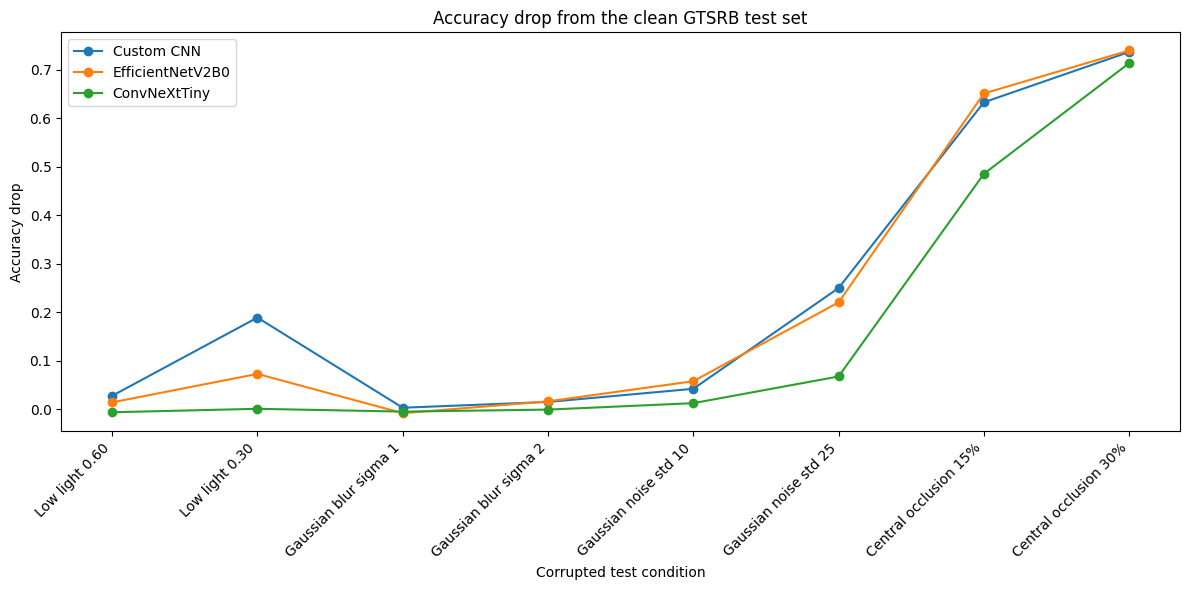

In [17]:
corrupted_rows = plot_frame[
    plot_frame[
        "condition"
    ]
    != "clean"
]


plt.figure(
    figsize=(
        12,
        6,
    )
)


for model_name in MODEL_PATHS:
    model_rows = corrupted_rows[
        corrupted_rows[
            "model"
        ]
        == model_name
    ]

    plt.plot(
        model_rows[
            "condition_label"
        ],

        model_rows[
            "accuracy_drop"
        ],

        marker="o",

        label=model_name,
    )


plt.xlabel(
    "Corrupted test condition"
)

plt.ylabel(
    "Accuracy drop"
)

plt.title(
    "Accuracy drop from the clean GTSRB test set"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.legend()

plt.tight_layout()


plt.savefig(
    FIGURE_DIR
    / "accuracy_drop.pdf",
    bbox_inches="tight",
)


plt.savefig(
    FIGURE_DIR
    / "accuracy_drop.png",
    dpi=180,
    bbox_inches="tight",
)


plt.show()

In [18]:
corrupted_summary = (
    corrupted_rows
    .groupby(
        "model",
        as_index=False,
    )
    .agg(
        average_corrupted_accuracy=(
            "accuracy",
            "mean",
        ),

        average_corrupted_macro_f1=(
            "macro_f1",
            "mean",
        ),

        average_accuracy_drop=(
            "accuracy_drop",
            "mean",
        ),

        average_macro_f1_drop=(
            "macro_f1_drop",
            "mean",
        ),

        worst_case_accuracy=(
            "accuracy",
            "min",
        ),

        worst_case_macro_f1=(
            "macro_f1",
            "min",
        ),
    )
)


clean_summary = (
    results_frame[
        results_frame[
            "condition"
        ]
        == "clean"
    ][
        [
            "model",
            "accuracy",
            "macro_f1",
            "top3_accuracy",
        ]
    ]
    .rename(
        columns={
            "accuracy":
            "clean_accuracy",

            "macro_f1":
            "clean_macro_f1",

            "top3_accuracy":
            "clean_top3_accuracy",
        }
    )
)


model_summary_frame = clean_summary.merge(
    corrupted_summary,
    on="model",
    how="left",
)


model_summary_frame.to_csv(
    REPORT_DIR
    / "robustness_model_summary.csv",
    index=False,
)


def select_best_model(
    frame: pd.DataFrame,
    column: str,
    highest: bool,
) -> str:
    # Select the best model after removing missing values.
    valid_rows = frame.dropna(
        subset=[
            column
        ]
    )

    if valid_rows.empty:
        return "Unavailable"

    if highest:
        index = valid_rows[
            column
        ].idxmax()

    else:
        index = valid_rows[
            column
        ].idxmin()

    return str(
        valid_rows.loc[
            index,
            "model",
        ]
    )


worst_condition_by_model = {}


for model_name in MODEL_PATHS:
    model_rows = corrupted_rows[
        corrupted_rows[
            "model"
        ]
        == model_name
    ]

    worst_row = model_rows.loc[
        model_rows[
            "accuracy"
        ].idxmin()
    ]

    worst_condition_by_model[
        model_name
    ] = {
        "condition": str(
            worst_row[
                "condition_label"
            ]
        ),

        "accuracy": float(
            worst_row[
                "accuracy"
            ]
        ),

        "macro_f1": float(
            worst_row[
                "macro_f1"
            ]
        ),

        "accuracy_drop": float(
            worst_row[
                "accuracy_drop"
            ]
        ),
    }


robustness_summary = {
    "best_clean_accuracy": (
        select_best_model(
            model_summary_frame,
            "clean_accuracy",
            highest=True,
        )
    ),

    "best_average_corrupted_accuracy": (
        select_best_model(
            model_summary_frame,
            "average_corrupted_accuracy",
            highest=True,
        )
    ),

    "best_average_corrupted_macro_f1": (
        select_best_model(
            model_summary_frame,
            "average_corrupted_macro_f1",
            highest=True,
        )
    ),

    "smallest_average_accuracy_drop": (
        select_best_model(
            model_summary_frame,
            "average_accuracy_drop",
            highest=False,
        )
    ),

    "smallest_average_macro_f1_drop": (
        select_best_model(
            model_summary_frame,
            "average_macro_f1_drop",
            highest=False,
        )
    ),

    "best_worst_case_accuracy": (
        select_best_model(
            model_summary_frame,
            "worst_case_accuracy",
            highest=True,
        )
    ),

    "worst_condition_by_model": (
        worst_condition_by_model
    ),
}


(
    REPORT_DIR
    / "robustness_summary.json"
).write_text(
    json.dumps(
        robustness_summary,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


display(
    model_summary_frame
)


print(
    json.dumps(
        robustness_summary,
        indent=2,
        ensure_ascii=False,
    )
)

,model,clean_accuracy,clean_macro_f1,clean_top3_accuracy,average_corrupted_accuracy,average_corrupted_macro_f1,average_accuracy_drop,average_macro_f1_drop,worst_case_accuracy,worst_case_macro_f1
0,ConvNeXtTiny,0.934917,0.890261,0.982660,0.776346,0.727616,0.158571,0.162645,0.220903,0.165265
1,Custom CNN,0.853682,0.805058,0.954236,0.616548,0.565496,0.237134,0.239562,0.116627,0.048844
2,EfficientNetV2B0,0.847348,0.768798,0.961124,0.626742,0.566542,0.220606,0.202256,0.107205,0.064298


{
  "best_clean_accuracy": "ConvNeXtTiny",
  "best_average_corrupted_accuracy": "ConvNeXtTiny",
  "best_average_corrupted_macro_f1": "ConvNeXtTiny",
  "smallest_average_accuracy_drop": "ConvNeXtTiny",
  "smallest_average_macro_f1_drop": "ConvNeXtTiny",
  "best_worst_case_accuracy": "ConvNeXtTiny",
  "worst_condition_by_model": {
    "Custom CNN": {
      "condition": "Central occlusion 30%",
      "accuracy": 0.1166270783847981,
      "macro_f1": 0.04884394852934883,
      "accuracy_drop": 0.7370546318289786
    },
    "EfficientNetV2B0": {
      "condition": "Central occlusion 30%",
      "accuracy": 0.10720506730007917,
      "macro_f1": 0.06429792616807885,
      "accuracy_drop": 0.7401425178147268
    },
    "ConvNeXtTiny": {
      "condition": "Central occlusion 30%",
      "accuracy": 0.2209026128266033,
      "macro_f1": 0.1652647803146011,
      "accuracy_drop": 0.7140142517814727
    }
  }
}


In [19]:
required_outputs = [
    REPORT_DIR
    / "robustness_results.csv",

    REPORT_DIR
    / "robustness_results_rounded.csv",

    REPORT_DIR
    / "robustness_model_summary.csv",

    REPORT_DIR
    / "robustness_summary.json",

    REPORT_DIR
    / "accuracy_table.csv",

    REPORT_DIR
    / "macro_f1_table.csv",

    REPORT_DIR
    / "accuracy_drop_table.csv",

    REPORT_DIR
    / "macro_f1_drop_table.csv",

    FIGURE_DIR
    / "corruption_examples.pdf",

    FIGURE_DIR
    / "robustness_accuracy.pdf",

    FIGURE_DIR
    / "robustness_macro_f1.pdf",

    FIGURE_DIR
    / "accuracy_drop.pdf",
]


missing_outputs = [
    path
    for path in required_outputs
    if not path.exists()
]


if missing_outputs:
    raise FileNotFoundError(
        f"Missing output files: {missing_outputs}"
    )


prediction_files = list(
    PREDICTION_DIR.glob(
        "*.csv"
    )
)


class_report_files = list(
    CLASS_REPORT_DIR.glob(
        "*.csv"
    )
)


print(
    "Prediction files:",
    len(prediction_files),
)


print(
    "Classification report files:",
    len(class_report_files),
)


if len(prediction_files) != 27:
    raise RuntimeError(
        "Expected 27 prediction files."
    )


if len(class_report_files) != 27:
    raise RuntimeError(
        "Expected 27 classification report files."
    )


print(
    "ROBUSTNESS TESTING COMPLETED SUCCESSFULLY."
)

Prediction files: 27
Classification report files: 27
ROBUSTNESS TESTING COMPLETED SUCCESSFULLY.


In [20]:
archive_path = shutil.make_archive(
    base_name=(
        "/kaggle/working/"
        "robustness_results"
    ),

    format="zip",

    root_dir=OUTPUT_ROOT,
)


archive_size_mb = (
    Path(
        archive_path
    ).stat().st_size
    / 1024
    / 1024
)


print(
    "Archive:",
    archive_path,
)


print(
    "Archive size, MB:",
    round(
        archive_size_mb,
        2,
    ),
)

Archive: /kaggle/working/robustness_results.zip
Archive size, MB: 7.57
